In [ ]:
# https://api.openweathermap.org/data/3.0/onecall/overview?lat={lat}&lon={lon}&appid={API key}

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel

class WeatherData(BaseModel):
    location: str
    weather: str
    seasonal_weather: str
    temperature: str
    summary: str

llm = ChatOpenAI(model="gpt-4o-mini",temperature=0.2).bind(response_format={"type": "json_object"})


llm_with_search = llm.bind_tools([{"type": "web_search"}])

response = llm_with_search.invoke([
    SystemMessage(content=f"""
                            You are a helpful weather assistant that can answer questions and help with tasks. Answer in a concise manner. If you are not sure or not have valid weather data, then provide me the seasonal weather forecast for the location based on the weather data available else provide me the weather data for the location.
                            provide me the weather data for the location in json format.

                            strictly output schema: {WeatherData}
                            output format:
                            {{
                                "location": "location name",
                                "weather": "rainfall/snowfall/sunny/cloudy/windy/foggy/cyclone/etc",
                                "seasonal_weather": "seasonal weather forecast",
                                "temperature": "temperature in celsius",
                                "summary": "summary of the weather in 3-4 lines. advice for trip based on the weather"
                            }}
    """),
    HumanMessage(content="What is the weather forecast for Malvan(Sindhudurg district)  on 10th of june?")
])


In [1]:
from langsmith import traceable,tracing_context

In [2]:
from typing import Any, Dict, List, Literal, Optional
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel


In [3]:

from operator import add
from typing import Annotated, Sequence

from langgraph.graph import add_messages
from langchain_core.messages import BaseMessage


class TravelState(BaseModel):
    # ── inputs ─────────────────────────────────────────────────────────────
    query: str = None
    # ── pipeline state ─────────────────────────────────────────────────────
    structured: Optional[Dict[str, Any]] = None
    follow_up_answers: Dict[str, str] = Field(default_factory=dict)
    weather: Optional[Any] = f"""
                                            As of May 15, 2026, specific weather forecasts for Malvan, Sindhudurg district, on June 10, 2026, are not available. However, based on historical climate data, we can provide an overview of the typical weather conditions for Malvan in June.
                                            June marks the onset of the monsoon season in Malvan, characterized by increased rainfall and humidity. The average temperature during this month is around 26.3°C, with maximum temperatures reaching up to 27.9°C and minimum temperatures around 25°C. The region receives substantial rainfall, averaging approximately 664 mm over the month. (en.climate-data.org)
                                            Given these conditions, if you're planning a trip to Malvan in June, it's advisable to prepare for wet and humid weather. Packing waterproof clothing and being prepared for occasional heavy rains will help ensure a comfortable visit.
                                        """
    itinerary: Optional[Dict[str, Any]] = None
    critique: Optional[Dict[str, Any]] = None
    suggestions: Optional[Dict[str, Any]] = None
    transport_results: Optional[Any] = None
    activities_results: Optional[Any] = None
    # ── control ────────────────────────────────────────────────────────────
    status: Literal["approved", "revise", "infeasible"] = "revise"
    iteration: int = 0
    maxIteration: int = 2
    user_current_intent: str = ""
    messages: Annotated[Sequence[BaseMessage],add_messages] = Field(default_factory=list)
    hotel_search_results: List[dict] = Field(default_factory=list)

    # flight search
    flights_data: dict = Field(default_factory=dict)

In [5]:
print(TravelState.model_fields.keys())

dict_keys(['query', 'structured', 'follow_up_answers', 'weather', 'itinerary', 'critique', 'suggestions', 'transport_results', 'activities_results', 'status', 'iteration', 'maxIteration', 'user_current_intent', 'messages', 'hotel_search_results', 'flights_data'])


In [44]:
secondary_llm = ChatOpenAI(model="gpt-5.4-mini-2026-03-17",temperature=0.2)

In [5]:
import datetime

class Duration(BaseModel):
    min_days: int
    max_days: int


class DateRange(BaseModel):
    start: str  # ISO-8601, e.g. "2026-05-01"
    end: str

class StructuredTravel(BaseModel):
    sourceLocation: str
    destinationLocation : str
    duration: Duration
    date_range: DateRange
    budget: Literal["low", "medium", "high"] = "medium"
    travel_style: Literal["solo", "couple", "family", "friends", "business" ] = "solo"
    number_of_people: int = 1
    mode_of_transport: Literal["flight", "train", "bus", "car"] = "flight"
    preferences: List[str] = []
    other_details: str = ""
    is_follow_up: bool = Field(default=False, description="Followup questions are required or not based on the user query")
    follow_up_questions: List[str] = []
    return_journey: bool = True
    accomodation_type: Literal["hotel", "guesthouse", "airbnb", "homestay"] = "hotel"
    month: str = Field(default="", description="Month of the trip")
    season: str = Field(default="", description="Weather season of the trip")


In [45]:

parser_llm = secondary_llm.with_structured_output(StructuredTravel)

def parserNode(state: TravelState) -> dict:
    today = datetime.date.today().isoformat()

    latest_message = state.messages[-1]
    prompt = f"""
                Today's date: {today}

                Extract structured travel information from the user query below.
                Be precise about dates: if only month names are given, infer the most likely year.
                Only checks for sourceLocation, destinationLocation, date_range, budget, travel_style, mode_of_transport, duration. 
                Ask for follow up questions if needed or any required details are missing, dont ask question just for the sake of it, empty list is fine.
                If user mentioned all of the details, then don't ask for follow up questions, just return the structured data with empty follow up questions.

                Ask follow up questions for only -
                sourceLocation, destinationLocation, date_range, budget, travel_style, mode_of_transport, duration.
            """

    parser_result = parser_llm.invoke([
        SystemMessage(content=prompt),
        HumanMessage(content=latest_message.content)
    ])

    print("parser node completed")

    return {"structured": parser_result.model_dump()}

In [7]:
from langgraph.types import interrupt


def follow_up_questions(state: TravelState) -> dict:
    structured = dict(state.structured or {})
    questions = structured.get("follow_up_questions") or []
    follow_up = structured.get("is_follow_up")

    if not questions or not follow_up:
        return {}

    answers = interrupt({
        "type": "follow_up_questions",
        "questions": questions,
    })

    # Normalize resume payload into {question: answer} for downstream use.
    if isinstance(answers, list):
        normalized = {
            q: str(answers[idx]) if idx < len(answers) else ""
            for idx, q in enumerate(questions)
        }
    elif isinstance(answers, dict):
        normalized = {str(k): str(v) for k, v in answers.items()}
    elif isinstance(answers, str):
        normalized = {questions[0]: answers}
    else:
        normalized = {"response": str(answers)}

    structured["follow_up_answers"] = normalized

    print("follow up questions node completed")
    return {
        "structured": structured,
        "follow_up_answers": normalized,
    }



In [8]:
import serpapi

In [9]:

client = serpapi.Client(api_key="460e88544987055f8956fe426076e0915a724c8f790fd0d070060b60498a90ab")

def serpapi_ai_mode(query: str):
    results = client.search({
        "documentation_path": "/google-ai-mode-api",
        "engine": "google_ai_mode",
        "q": query,
        "hl": "en",
        "gl": "us"
    })

    return results

In [60]:
transport_bundle = """
{source} to {destination} transport options flight train distance time,
nearest airport railway-station {destination},
nearest airport railway-station {source},
local transport in {destination} taxi rental availability
"""

In [11]:
activities_bundle = """
things to do in {destination} {month} weather,
tourist attractions and places to visit in {destination},
nearby sightseeing and cultural places
"""

In [12]:
import re
import json

def clean_text(text: str) -> str:

    if not text:
        return ""

    # -----------------------------------
    # Convert markdown links
    # [text](url) -> text
    # -----------------------------------

    text = re.sub(
        r"\[([^\]]+)\]\([^)]+\)",
        r"\1",
        text
    )

    # -----------------------------------
    # Remove standalone URLs
    # -----------------------------------

    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # -----------------------------------
    # Remove brackets but KEEP text
    # [text] -> text
    # -----------------------------------

    text = re.sub(
        r"\[([^\]]+)\]",
        r"\1",
        text
    )

    # -----------------------------------
    # Remove parentheses but KEEP text
    # (text) -> text
    # -----------------------------------

    text = re.sub(
        r"\(([^)]+)\)",
        r"\1",
        text
    )

    # -----------------------------------
    # Remove markdown symbols
    # -----------------------------------

    text = re.sub(
        r"[#>*`_~-]",
        "",
        text
    )

    # -----------------------------------
    # Normalize whitespace
    # -----------------------------------

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [13]:
def transport_search_node(state: TravelState):
    """Search for transport options between source and destination"""
    source = state.structured.get("sourceLocation", "")
    destination = state.structured.get("destinationLocation", "")

    query = transport_bundle.format(source=source, destination=destination)
    transport_results = serpapi_ai_mode(query)

    transport_results = clean_text(transport_results.get("reconstructed_markdown", ""))

    print("transport search node completed")
    return {
        "transport_results": {
            "query": query,
            "reconstructed_markdown": transport_results,
        }
    }


# transport_search_node("mumbai", "malvan")
# reconstructed_markdown

In [14]:
def activities_search_node(state: TravelState):
    """Search for activities in the nearby destination"""
    source = state.structured.get("sourceLocation", "")
    destination = state.structured.get("destinationLocation", "")
    style = state.structured.get("travel_style", "family")
    month = state.structured.get("month", "")
    season = state.structured.get("season", "")

    query = activities_bundle.format(source=source, destination=destination, style=style, month=month, season=season)

    activities_results = serpapi_ai_mode(query)
    activities_results = clean_text(activities_results.get("reconstructed_markdown", ""))

    print("activities search node completed")
    return {
        "activities_results": {
            "query": query,
            "reconstructed_markdown": activities_results,
        }
    }


# transport_search_node("mumbai", "malvan")

In [46]:
class Plan(BaseModel):
    morning: List[str] = Field(
        ..., 
        description="1-2 Activities planned for the morning hours. Nothing else, only activity description."
    )
    afternoon: List[str] = Field(
        ..., 
        description=" 1-2 Activities planned for the afternoon hours. Nothing else, only activity description."
    )
    evening: List[str]  = Field(
        ..., 
        description=" 1-2 Activities planned for the evening hours. Nothing else, only activity description."
    )

class DayPlan(BaseModel):
    day: int
    location: str
    plan: List[Plan] = Field(description="3-5 specific actions for that day for morning, afternoon and evening each")


class ItineraryOutput(BaseModel):
    summary: str
    days: List[DayPlan]


planner_llm = secondary_llm.with_structured_output(ItineraryOutput)


def planner_node(state: TravelState) -> dict:
    s = state.structured or {}

    source = s.get("sourceLocation", "")
    destination = s.get("destinationLocation", "")
    start = (s.get("date_range") or {}).get("start", "")
    end = (s.get("date_range") or {}).get("end", "")
    budget = s.get("budget", "medium")
    style = s.get("travel_style", "family")
    people = s.get("number_of_people", 1)
    transport_mode = s.get("mode_of_transport", "flight")
    preferences = ", ".join(s.get("preferences") or []) or "none"
    other_details = s.get("other_details", "")
    follow_up_answers = state.follow_up_answers or (s.get("follow_up_answers") or {})
    weather = state.weather

    duration = (s.get("duration") or {}).get("max_days")
    if not duration and start and end:
        try:
            start_dt = datetime.date.fromisoformat(start)
            end_dt = datetime.date.fromisoformat(end)
            duration = max(1, (end_dt - start_dt).days + 1)
        except Exception:
            duration = 5
    duration = duration or 5

    transport_data = state.transport_results or {}
    activities_data = state.activities_results or {}

    if isinstance(transport_data, dict):
        transport_text = str(transport_data.get("reconstructed_markdown") or transport_data)
    else:
        transport_text = str(transport_data)

    if isinstance(activities_data, dict):
        activities_text = str(activities_data.get("reconstructed_markdown") or activities_data)
    else:
        activities_text = str(activities_data)

    evidence_block = f""" \n
                        Transport:
                        {transport_text}

                        \n
                        Activities:
                        {activities_text}
                    """

    system_prompt = f"""
You are a senior travel operations planner.

Your job is to create a REALISTIC, EXECUTABLE, WEATHER-AWARE,
and GEOGRAPHICALLY EFFICIENT travel itinerary.

You are NOT a travel blogger.
You are NOT generating generic sightseeing suggestions.

You must optimize for:
- realistic transportation
- traveler comfort
- weather safety
- geographic efficiency
- reduced fatigue
- practical execution
- budget alignment

==================================================
TRIP DETAILS
==================================================

FROM: {source}
TO: {destination} \n

DATES:
{start} to {end} \n

TOTAL DAYS:
{duration} \n

TRAVELERS:
{people} \n

TRAVEL STYLE:
{style} \n

BUDGET:
{budget} \n

PREFERRED TRANSPORT:
{transport_mode} \n

PREFERENCES:
{preferences} \n

OTHER DETAILS:
{other_details} \n

FOLLOW-UP ANSWERS:
{follow_up_answers} \n

==================================================
WEATHER DATA
==================================================

{weather} \n

==================================================
WEB EVIDENCE
==================================================

{evidence_block} \n

==================================================
CRITICAL PLANNING RULES
==================================================

1. SAFETY FIRST
- Avoid unsafe activities.
- Respect weather risks.
- Avoid sea/boat activities during dangerous conditions.
- Add contingency suggestions when weather disruption is possible.

2. TRANSPORT REALISM
- Use realistic travel durations.
- Consider airport/train transfer time.
- Avoid excessive daily travel.
- Minimize fatigue for {people} travelers.

3. WEATHER-AWARE PLANNING
- Adapt activities according to weather.
- During heavy rain:
  - prefer indoor/cultural activities
  - avoid risky outdoor plans
  - reduce overpacked schedules

4. GEOGRAPHIC OPTIMIZATION
- Group nearby attractions together.
- Avoid zig-zag movement between distant places.
- Optimize route efficiency.

5. FAMILY/GROUP COMFORT
- Add buffer time.
- Avoid exhausting schedules.
- Include relaxed evening activities after long travel.

6. FOOD & CULTURE
- Include authentic local food experiences.
- Include culturally relevant attractions.
- Recommend realistic local dining experiences.

==================================================
ITINERARY FORMAT RULES
==================================================

Generate EXACTLY {duration} days.

For EACH day include:

- Morning
- Afternoon
- Evening

Each section must contain:
- specific activities, If plan A is not possible, then plan B or the alternative plan only, nothing else, dont give multiple plans for each activities, only use it when there is a change in weather or any other serious/critical reason.
- transportation/logistics notes
- weather-aware recommendations

Include:
- estimated local travel
- practical advice
- booking recommendations
- weather precautions

==================================================
STRICTLY AVOID
==================================================

- generic filler text
- repetitive activities
- fabricated timings
- impossible transport plans
- weather-incompatible activities
- excessive travel in one day

If evidence is uncertain:
say so clearly instead of hallucinating.

==================================================
OUTPUT FORMAT
==================================================

Return structured JSON matching itinerary schema.
"""

    result: ItineraryOutput = planner_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content="Create the complete itinerary now."),
    ])

    return {"itinerary": result.model_dump()}


In [16]:
def followup_route(state: TravelState):
    if state.structured.get("is_follow_up"):
        return "follow_up_questions"
    else:
        return "web_queries"


In [18]:
def web_queries(state: TravelState):
    """Junction node for branching to search workers via graph edges."""
    if not state.structured:
        return {}
    return {}


In [73]:
class IntentOutput(BaseModel):

    intent: Literal[
        "plan_trip",
        "modify_itinerary",
        "book_hotel",
        "get_info",
        "general_chat",
        "flight_search"
    ] = Field(description="The intent of the user query",default="general_chat")
    # confidence: float = Field(description="The confidence score of the intent",default=0.0)
    # extracted_entities: List[str] = Field(description="The extracted entities from the user query",default=[])

In [74]:
from langchain_core.messages import AIMessage


intent_llm = secondary_llm.with_structured_output(IntentOutput)

def extract_user_intent(state: TravelState):
    """Extract user intent from the query"""

    SYSTEM_PROMPT = """
    You are a senior conversation classification agent.
    Your job is to extract the intent of the user query.
    Only answer the query related to the trip/travel releted question.

    Return the intent in json format only.
    """

    latest_message = state.messages[-1]

    result = intent_llm.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=latest_message.content)
    ])  

    print("result.model_dump()",result.model_dump())

    intent = result.model_dump().get("intent")

    print("extract_user_intent completed",intent)
    return {"user_current_intent": intent}


In [75]:
def intent_route(state: TravelState):
    
    return state.user_current_intent or "general_chat"


In [76]:
def test_node(state: TravelState):
    print("test node completed",state.user_current_intent)
    return {}


In [77]:
class UpdateStructuredTravel(BaseModel):
    sourceLocation: str
    destinationLocation : str
    duration: Duration
    date_range: DateRange
    budget: Literal["low", "medium", "high"] = "medium"
    travel_style: Literal["solo", "couple", "family", "friends", "business" ] = "solo"
    number_of_people: int = 1
    mode_of_transport: Literal["flight", "train", "bus", "car"] = "flight"
    preferences: List[str] = []
    other_details: str = ""
    return_journey: bool = True
    accomodation_type: Literal["hotel", "guesthouse", "airbnb", "homestay"] = "hotel"
    month: str = Field(default="", description="Month of the trip")
    season: str = Field(default="", description="Weather season of the trip")

def modify_itinerary(state: TravelState):
    
    query = state.messages[-1].content

    SYSTEM_PROMPT = f"""
    You are a senior travel operations planner.
    Your job is to modify the structured data based on the user query and the data provided.
    Only update the structured data if the user ask to update it, otherwise return the same structured data.
    Dont update full structured data only update the data that is asked by the user.

    Strictly return the structured data in json format only.
    Exsisting Structured Data: \n
    {state.structured}
    """

    print("modify_itinerary query",query)

    result = secondary_llm.with_structured_output(UpdateStructuredTravel).invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=query)
    ])

    merged = {
        **(state.structured or {}),
        **result.model_dump()
    }

    print("modify_itinerary completed",merged)

    return {"structured": merged}

In [24]:
def hotel_search_api(query: str,start_date: str,end_date: str,budget: str,number_of_people: int,accomodation_type: str,travel_style: str):
    client = serpapi.Client(api_key="460e88544987055f8956fe426076e0915a724c8f790fd0d070060b60498a90ab")

    query = f"{query} {accomodation_type} {budget} budget for {travel_style}"

    results = client.search({
        "documentation_path": "/google-hotels-api",
        "engine": "google_hotels",
        "q": query,
        "hl": "en",
        "gl": "in",
        "check_in_date": start_date,
        "check_out_date": end_date,
        "currency": "INR",
        "no_cache": "true",
        "adults": number_of_people,
        "children": 0,      
    })

    properties = results.get("properties",[])

    print("hotel search api",len(properties))
    return properties

In [25]:
def hotel_search_node(state: TravelState):

    query = state.structured.get("destinationLocation", "")
    start_date = state.structured.get("date_range", {}).get("start", "")
    end_date = state.structured.get("date_range", {}).get("end", "")
    budget = state.structured.get("budget", "medium")
    number_of_people = state.structured.get("number_of_people", 1)
    accomodation_type = state.structured.get("accomodation_type", "hotel")
    travel_style = state.structured.get("travel_style", "family")
    

    result = hotel_search_api(query,start_date,end_date,budget,number_of_people,accomodation_type,travel_style)

    print("hotel search node completed", len(result))
    return {"hotel_search_results": result}

In [78]:
def flight_search_api(outbound_date: str,return_date: str,dep_id: str,arr_id: str,number_of_people: int):
    client = serpapi.Client(api_key="460e88544987055f8956fe426076e0915a724c8f790fd0d070060b60498a90ab")

    results = client.search({
                "documentation_path": "/google-flights-api",
                "engine": "google_flights",
                "hl": "en",
                "gl": "in",
                "departure_id": dep_id,
                "arrival_id": arr_id,
                "outbound_date": outbound_date,
                "return_date": return_date,
                "currency": "INR",
                "adults": number_of_people,
                "children": 0,
                "deep_search": "true"
            })

    best_flights = results.get("best_flights",[])
    other_flights = results.get("other_flights",[])
    airports = results.get("airports",[])

    print("flight search api",len(best_flights),len(other_flights),len(airports))
    return { 
        "best_flights": best_flights, 
        "other_flights": other_flights, 
        "airports": airports
    }

In [ ]:
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# 1. Define the schema for the items inside the lists
class LocationDetails(BaseModel):
    name: str
    code: str
    location: str

# 2. Define the main output schema
class FlightSearchOutput(BaseModel):
    departure_airport_code: str
    arrival_airport_code: str
    departure_airport_name: str
    arrival_airport_name: str
    
    # 3. Reference the sub-model inside the standard list type hint
    other_airports: list[LocationDetails] = Field(default_factory=list)
    nearest_railway_station: list[LocationDetails] = Field(default_factory=list)


llm = ChatOpenAI(model="gpt-5-mini-2025-08-07",temperature=0.2)
llm_with_search = llm.with_structured_output(FlightSearchOutput)

def flight_search_node(state:TravelState):
    print("flight search node started")
    outbound_date = state.structured.get("date_range", {}).get("start", "")
    return_date = state.structured.get("date_range", {}).get("end", "")
    number_of_people = state.structured.get("number_of_people", 1)

    result = llm_with_search.invoke([
        SystemMessage(content="""You are a helpful assistant.  Help to extract the information from the web search result in json format.
                                return json fromat only. no text, no markdown, no html, no code, no anything else, only json object. 
                                  return the json in the given schema                         
                                 """
                        ),
        HumanMessage(content=f"web search result: \n {state.transport_results}")
    ])


    search_data = result.model_dump()
    print("flight search node result", search_data)

    api_data = flight_search_api(
        outbound_date,
        return_date,
        search_data["departure_airport_code"],
        search_data["arrival_airport_code"],
        number_of_people
    )

    print("flight search node completed")
    return {
        "flights_data": {
            "best_flights": api_data["best_flights"],
            "other_flights": api_data["other_flights"],
            "airports": api_data["airports"]
        }
    }

In [97]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

workflow = StateGraph(TravelState)

workflow.add_node("extract_user_intent", extract_user_intent)
workflow.add_node("parser", parserNode)
workflow.add_node("follow_up_questions", follow_up_questions)
workflow.add_node("transport_search", transport_search_node)
workflow.add_node("activities_search", activities_search_node)
workflow.add_node("planner", planner_node)
workflow.add_node("web_queries", web_queries)
workflow.add_node("hotel_search", hotel_search_node)
workflow.add_node("flight_search", flight_search_node)

workflow.add_node("test_node", test_node)
workflow.add_node("modify_itinerary", modify_itinerary)

workflow.add_edge(START, "extract_user_intent")
workflow.add_conditional_edges("extract_user_intent", intent_route,{
    "plan_trip": "parser",
    "modify_itinerary": "modify_itinerary",
    "flight_search": "flight_search",
    "book_hotel": "hotel_search",
    "get_info": "test_node",
    "general_chat": "test_node",
})
workflow.add_edge("modify_itinerary","web_queries")
workflow.add_edge("hotel_search",END)
workflow.add_edge("flight_search",END)

workflow.add_conditional_edges("parser", followup_route,{
    "follow_up_questions": "follow_up_questions",
    "web_queries": "web_queries",
})

workflow.add_edge("follow_up_questions", "web_queries")

workflow.add_edge("web_queries", "transport_search")
workflow.add_edge("web_queries", "activities_search")

workflow.add_edge("transport_search", "planner")
workflow.add_edge("activities_search", "planner")

workflow.add_edge("planner", END)

graph = workflow.compile(checkpointer=memory)

In [91]:
config = {"configurable": {"thread_id": "3"}}


In [99]:
from langgraph.types import Command

with tracing_context(enabled=False,project_name="trip planner",metadata={"user": "pratham", "thread_id": "2"}):
    first = graph.invoke(
        {
            "messages":[HumanMessage(content="book flights for this trip")],
        },
        config,
    )

# For interrupt flows, inspect the checkpoint snapshot.
snapshot = graph.get_state(config)
interrupts = snapshot.interrupts

if interrupts:
    payload = interrupts[0].value
    questions = payload.get("questions", [])
    user_answers = {q: input(f"{q}\n> ").strip() for q in questions}
    result = graph.invoke(Command(resume=user_answers), config)
else:
    result = first

result

result.model_dump() {'intent': 'flight_search'}
extract_user_intent completed flight_search
flight search node started


AttributeError: 'FlightSearchOutput' object has no attribute 'content'

In [ ]:
result

dict_keys(['query', 'structured', 'follow_up_answers', 'weather', 'itinerary', 'critique', 'suggestions', 'transport_results', 'activities_results', 'status', 'iteration', 'maxIteration', 'user_current_intent', 'messages', 'hotel_search_results', 'flights_data'])


<generator object Pregel.stream at 0xa08caed10>

In [65]:
graph.get_state(config).values["structured"]

{'sourceLocation': 'Mumbai',
 'destinationLocation': 'Goa',
 'duration': {'min_days': 5, 'max_days': 5},
 'date_range': {'start': '2026-07-01', 'end': '2026-07-05'},
 'budget': 'medium',
 'travel_style': 'couple',
 'number_of_people': 2,
 'mode_of_transport': 'flight',
 'preferences': ['restaurant/dining reservations'],
 'other_details': '',
 'is_follow_up': False,
 'follow_up_questions': [],
 'return_journey': True,
 'accomodation_type': 'hotel',
 'month': 'July',
 'season': 'monsoon'}

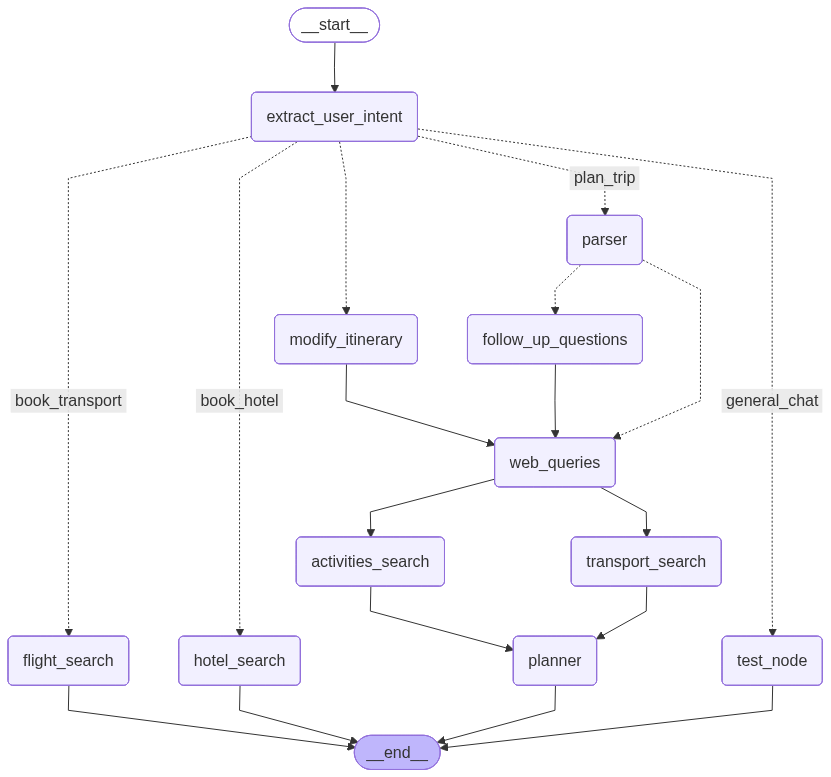

In [29]:
graph


In [98]:
graph.update_state(config,
{'structured': {'sourceLocation': 'Mumbai',
  'destinationLocation': 'Goa',
  'duration': {'min_days': 5, 'max_days': 5},
  'date_range': {'start': '2026-07-01', 'end': '2026-07-05'},
  'budget': 'medium',
  'travel_style': 'couple',
  'number_of_people': 2,
  'mode_of_transport': 'flight',
  'preferences': ['restaurant/dining reservations'],
  'other_details': '',
  'is_follow_up': False,
  'follow_up_questions': [],
  'return_journey': True,
  'accomodation_type': 'hotel',
  'month': 'July',
  'season': 'monsoon'},
 'itinerary': {'summary': '5-day, weather-aware Goa itinerary (1–5 July 2026) for a couple flying from Mumbai. Base: Panaji / central Goa (easy access to North attractions and central day trips). Prioritises short transfers, monsoon-safe activities, local dining reservations, and one optional Dudhsagar day trip with a built-in weather contingency. Travel mode: flight Mumbai–Goa (recommended to/from Dabolim GOI for central location) + short private taxi/rented car for day trips. Safety note: July is monsoon — avoid open-sea swimming and small boat trips when seas are rough; several activities include Plan B alternatives if heavy rain or local closures occur.',
  'days': [{'day': 1,
    'location': 'Panaji / Fontainhas (central Goa)',
    'plan': [{'morning': ['Arrive Goa by flight from Mumbai (choose Dabolim/GOI for central access). Logistics: allow 45–75 minutes for disembark, baggage and customs, then pre-paid taxi or GoaMiles transfer to Panaji (approx. 30–50 min, depending on traffic). Practical advice: book airport taxi in advance via GoaMiles or request hotel pickup. Weather precaution: expect heavy rain and puddled roads; use covered taxi and waterproof bags for luggage. Booking recommendation: pick a morning flight to maximise the day and confirm hotel early-check or baggage hold if arriving before check-in.'],
      'afternoon': ["Hotel check-in and relaxed lunch — reserve a table at Mum's Kitchen (Panaji) or similar authentic Goan restaurant (book 24–48 hr ahead). Logistics: short drive 5–15 min from central Panaji hotels. Estimated local travel: 10–30 min including traffic. Weather note: Fontainhas walk is next; if rain is light, do a 60–90 minute guided walk of Fontainhas Latin Quarter (narrow lanes, colourful Portuguese houses). Plan B (if heavy rain): visit Indo-Portuguese Museum and nearby art galleries (indoor, similar cultural value). Booking recommendation: book the Fontainhas walk or museum tickets in advance where possible; carry a compact umbrella and non-slip shoes."],
      'evening': ['Riverside stroll along Mandovi (short taxi 5–15 min) and dinner at a riverside restaurant — reserve a table with river view. Logistics: expect 20–40 minutes including walking and light traffic. Practical advice: choose restaurants with covered seating in case of downpour; avoid last-minute street-side tables during heavy rain. Weather precaution: skip any short river cruises if river conditions are choppy or authorities advise suspension.']}]},
   {'day': 2,
    'location': 'North Goa — Aguada / Candolim / Vagator',
    'plan': [{'morning': ['Drive north to Fort Aguada and Candolim for cliff/fort views and a beach walk (private taxi or rented car, 30–50 min from Panaji). Logistics: depart after breakfast to avoid mid-day rains; estimated local travel 30–50 min each way. Weather-aware: fort and cliff views are best in light rain; avoid slippery edges during heavy rain. Practical advice: wear closed shoes; carry waterproof jacket.'],
      'afternoon': ['Lunch reservation in Assagao or Vagator — recommend Gunpowder (Assagao) or similar for well-reviewed regional cuisine (book 24–48 hr ahead). After lunch, visit a nearby café or boutique art store (short drives 10–20 min). Weather Plan B (if steady/heavy rain): skip beach walk and instead visit indoor galleries or a short cooking class (book in advance). Logistics: keep taxi for flexible short hops; estimated local travel 10–30 min between stops.'],
      'evening': ['Sunset viewpoint at Vagator cliffs (if weather permits) followed by dinner at a restaurant with covered outdoor seating (reserve ahead). Logistics: 10–25 min drive from afternoon area; allow extra travel time if roads are wet. Safety note: do not attempt cliff-edge selfies during heavy rain or wind; if cliff access is closed, Plan B is a relaxed hotel dinner with live music (reserve a table).']}]},
   {'day': 3,
    'location': 'Dudhsagar Falls / Mollem area (east Goa) — weather-critical day trip',
    'plan': [{'morning': ['Early departure by private car (recommended driver/agency) to Dudhsagar Falls area (Mollem/Sonulem region). Logistics: 2–2.5 hours one-way from Panaji depending on route/traffic; start early to avoid afternoon heavy rains. Important booking: reserve jeep safari seats/permit and authorised operator in advance (safari capacity is limited in monsoon). Weather caution: jeep safaris and railway-side access can be suspended during heavy rain or when tracks/roads are unsafe — confirm with operator the day before departure.'],
      'afternoon': ["Primary Plan A (if safaris open and weather moderate): Dudhsagar jeep safari and short, guided walk to viewpoint; carry waterproofs, quick-dry clothes, and sturdy footwear. Logistics: full-day trip — expect 8–10 hours total including returns; bring snacks/water or request packed lunch from hotel. Weather precaution: if rainfall intensifies, drivers/guides will halt access for safety; follow local authorities' instructions promptly. Plan B (if Dudhsagar is closed due to heavy rain): visit a nearby spice plantation (Sahakari-style) for a guided tour and traditional Goan lunch, then Tambdi Surla temple and a short scenic drive through Chorla Ghat — these are largely road-based and offer a safe monsoon alternative. Booking recommendation: pre-book either the Dudhsagar operator or the spice-plantation combo; ensure the operator provides a refundable/cancellable option if weather cancels the jeep."],
      'evening': ['Return to Panaji; relaxed dinner near hotel with a reservation (choose a calmer menu after a long day). Logistics: allow extra buffer on return (roads slow in rain). Practical advice: rest after long day trip; keep evening low-key to reduce fatigue.']}]},
   {'day': 4,
    'location': 'Old Goa, Chorao Island / Salim Ali Bird Sanctuary',
    'plan': [{'morning': ['Visit Old Goa (Basilica of Bom Jesus, Se Cathedral, and nearby museums). Logistics: 25–40 min drive from Panaji. Weather-aware: churches and museums are indoor/covered — good monsoon activity. Practical advice: hire a local guide (book in advance) to avoid standing in queues and to get contextual history efficiently.'],
      'afternoon': ['Take the short ferry to Chorao Island for a guided mangrove canoe/boat through the Salim Ali Bird Sanctuary (ferry + guided canoe total 60–120 min). Logistics: ferry departs from Ribandar/Chorao — allow 20–40 min transfer time including waiting. Weather Plan B (if river/mangrove boat trips are suspended due to rough conditions): substitute with Goa State Museum + walking Latin Quarter food trail in Fontainhas with pre-booked food stops (book food-trail slots 48+ hours ahead). Safety note: boats are cancelled in heavy rains — confirm with operator the morning of departure.'],
      'evening': ['Latin Quarter food trail or reserve dinner at a well-reviewed Panaji restaurant showcasing Goan cuisine (book table). Logistics: short transfers within Panaji (10–20 min). Practical advice: carry rain-protective footwear for narrow lanes and book an indoor table during monsoon; expect aroma-rich, spicy Goan dishes — request milder versions if preferred.']}]},
   {'day': 5,
    'location': 'Panaji — departure to Mumbai',
    'plan': [{'morning': ['Leisurely morning: Miramar beach walk or short visit to local market for souvenirs (short drive 10–20 min). Logistics: keep activity low-energy to prepare for travel. Weather note: beach walk for views only — avoid swimming; wet sands can be slippery after rain. Booking recommendation: if you want one last special brunch, reserve a table at your hotel or a nearby café.'],
      'afternoon': ['Hotel check-out and transfer to Dabolim Airport. Logistics: allow 2.5–3.5 hours from Panaji to international/domestic airport for monsoon traffic and security (include 90–120 min airport arrival buffer recommended). Practical advice: confirm taxi pickup 3–4 hours before flight departure; keep a physical copy of flight booking and ID accessible.'],
      'evening': ['Fly back to Mumbai. Weather precaution: monsoon can cause flight delays — keep flexible refundable options and check flight status the morning of travel. If flights are delayed, use airline assistance desks at the airport; hotels/drivers can help rebook if required.']}]}]},
 'transport_results': {'query': '\nMumbai to Goa transport options flight train distance time,\nnearest airport railway station Goa,\nlocal transport in Goa taxi rental availability\n',
  'reconstructed_markdown': "Traveling from Mumbai to Goa is a highly connected corridor with multiple air, rail, and road options. 23 24 25 26 Mumbai to Goa Transport Options Flight: This is the fastest method, taking 1 hour to 1 hour 25 minutes. The aerial distance is about 425 km. Airlines like IndiGo and Air India operate daily nonstop flights. Train: The rail distance is roughly 715 km to 760 km along the scenic Konkan Railway. Travel times vary drastically by train: the high\\speed Vande Bharat Express takes roughly 6.5 to 7.5 hours, while standard express trains \\like the Mandovi Express\\ take 10 to 12 hours. Road \\Car/Bus\\: The driving distance is approximately 540 km to 600 km. It takes 11 to 14 hours depending on traffic and the highway route chosen. Over\\night sleeper luxury buses run daily. Nearest Airports & Railway Stations in Goa Goa is uniquely split into North and South tourist belts. Choosing your transit hub depends entirely on where your hotel is located: Nearest Airports: Manohar International Airport \\GOX\\ at Mopa: Located in extreme North Goa. Best if you are staying in Vagator, Anjuna, Calangute, or Morjim. Goa Dabolim International Airport \\GOI\\: Located in Central\\South Goa. Best if you are staying in Panaji, Colva, Palolem, or Vasco da Gama. Nearest Railway Stations: Thivim \\THVM\\: The main station for North Goa beaches. Madgaon / Margao \\MAO\\: The largest and busiest junction, ideal for South Goa. Vasco Da Gama \\VSG\\: Located in central\\west Goa, closest to Dabolim. Local Transport in Goa: Taxis & Rentals Traditional ride\\hailing apps like Uber and Ola do not operate freely within Goa due to local union regulations. However, multiple convenient alternatives exist: 13 16 28 29 App\\Based Taxis: You can use GoaMiles, the government\\backed official taxi app. It provides transparent, fixed\\rate pricing and can be booked directly for airport pickups or point\\to\\point travel. Prepaid Taxi Counters: Available directly outside the arrivals terminals at both Mopa and Dabolim airports, as well as major train stations. Fares are fixed by the government based on your destination zone. Self\\Drive Car & Scooter Rentals: Highly popular and cost\\effective. You can rent scooters \\typically ₹400–₹600/day\\ or cars \\typically ₹1,500–₹4,000/day\\ from local vendors near beaches and transit hubs. Ensure the vehicle has a black license plate with yellow lettering, which marks it as a legal commercial rental. To give you more specific advice, please let me know: Which area or beach in Goa are you planning to stay in? What is your preferred balance between budget and travel speed? Are you traveling solo, as a couple, or with a large family? References 0 Mumbai to Goa Cabs @ ₹9218 \\up to ₹500 off\\ \\| Uber Intercity — Transportation options \\ Uber: Request an Uber ride from Mumbai to Goa. The journey covers approximately 554 kilometers and takes ... 1 How to Travel From Mumbai to Goa by Train, Bus, Plane, and Car — May 17, 2020 — Table\\title: How to Travel From Mumbai to Goa by Train, Bus, Plane, and Car Table\\content: header: \\| \\| Time \\| Cost \\| row: \\| : Trai... 2 How to Reach Goa: By Air, Train, Bus & Road \\ EaseMyTrip — Goa is well\\connected to different parts of India and the world. Here are the best ways to reach this stunning coastal state: By A... 3 Mumbai Airport \\BOM\\ to Goa \\ 10 ways to travel via train, plane, and ... — The distance between Mumbai Airport \\BOM\\ and Goa is 428 km. The road distance is 547.9 km. ... How do I travel from Mumbai Airpor... 4 Mumbai to Goa Airport \\GOI\\ \\ 8 ways to travel via train, plane, and bus — The distance between Mumbai and Goa Airport \\GOI\\ is 436 km. The road distance is 538.1 km. ... How do I travel from Mumbai to Goa... 5 Goa Dabolim International Airport — Goa's famous beaches are accessed from this hub with separate international and domestic terminals. 6 Mumbai to Goa Flights, Ticket Fare from INR 2,859 \\| Air India — Table\\title: Information on flights from Mumbai to Goa Table\\content: header: \\| Mumbai to Goa flight distance \\| 435 km/270 miles \\| 7 Mumbai to Goa Distance\\ 594 Km \\ MakeMyTrip — Showing Best Flights For Sun, 21 Jun 2026. 1 Adult \\| Economy. IndiGo. 6E\\5177. 19:10 Mumbai. 01 h 15 m Non stop. 20:25. Goa \\North... 8 GoaMiles \\ App Store \\ Apple — GoaMiles Taxi service enhances Goa travel for tourists and locals. Offering professional drivers, it ensures a seamless journey wi... 9 Mumbai to Goa Trains \\| 52 Trains with Timings, Price ... \\ redBus — 22:30. 14 hrs 55 mins. \\ JBP CBE SPECIAL \\(02198\\ 15:25. 01:35. 10 hrs 10 mins. ₹520. NZM TVC SF SPL \\04440\\ 11:25. 21:00. 09 hrs 3... 10 Mumbai to Goa in just 6.5 hours? Yes, it’s real 🚆✨ The Vande ... — Mar 17, 2026 — 📍 Route: Mumbai \\CSMT\\ ➝ Madgaon \\Goa\\ 🕒 Travel Time: Approx, 6.5hrs\\thivim\\. 7.5hrs \\Madgaon\\ ⚡ Train No.: 22229. ⏰ Departure \\ 11 Mumbai to Goa Trains \\ 17 Trains Ticket Price, Time ... \\ Ixigo — Table\\title: Daily Trains from Mumbai to Goa Table\\content: header: \\| Train Name \\(No.\\ \\| Day of Departure \\| Total Time of Travel \\| 12 Mumbai to Goa Distance \\ 425 km, Flight, Road \\ Ixigo — Mumbai to Goa Distance via Flight Flying from Mumbai to Goa is one of the quickest and most convenient ways to travel between the ... 13 Where is the Goa Taxi App? \\ Reddit — Oct 29, 2023 — black\\jar. • 3y ago. Avoid the taxi apps. They don't work in Goa. You will need to negotiate on ground. For now take a pre paid ta... 14 Mumbai to Goa Trains: Book from 17 Trains, Check Fares, Timetable — Mumbai to Goa Train Distance The distance between Mumbai and Goa is approximately 760km. Mumbai to Goa distance by train is covere... 15 Airports in Goa, List of Goa Airports \\ IndiGo — 1. Manohar International Airport. Manohar International Airport or Mopa Airport is located 35 kilometres from Panjim, this newly b... 16 Which is the best cab service in Goa? \\ Quora — Apr 3, 2017 — GoaMiles, it's the only app based taxi service available in Goa. It's the cheapest and most efficient taxi service and works like ... 17 unstumbled \\| Goa has TWO airports. Yes, two. And no, they are not ... — Mar 4, 2026 — There's Manohar International Airport that's known as Mopa, and then there's Dabolim airport. Mopa mostly serves North Goa and Dab... 18 Goa Airport Guide: What You Need to Know for a Beach Getaway — Sep 21, 2025 — Location and Accessibility. The most significant difference between the two airports is their geographical location. Dabolim Airpo... 19 Goa has two main operational airports, Dabolim Airport or Goa ... — Dec 27, 2025 — Goa has two main operational airports, Dabolim Airport or Goa International Airport \\GOI\\ in South Goa and Mopa Airport or Manohar... 20 Goa Airports Guide 2026: Terminals, Transport & Tips \\ Secret Flying — Manohar International Airport, Goa \\GOX / GOI\\ Overview: This is Goa's new, primary international airport. Opened in 2022 and loca... 21 🚖 Exploring Goa? Your ride’s just a tap away\\! 🌴✨ Book a cab in ... — Aug 12, 2025 — Your ride's just a tap away\\! 🌴✨ Book a cab in seconds with the GoaMiles App – simply enter your destination, pick your ride \\Hatc... 22 Flights from Mumbai to Goa — Round trip flights to Goa starting from $60 23 Distance Between Mumbai to Goa Is 604 Kms , Duration, Driving Directions \\u0026 Route Map — A. The various mode of transport between Mumbai to Goa are by road, by train or by flight. Traveler can choose any mode of transpo... 24 How to Reach Goa by Flight, Train, Car or Bus \\ Delhi — Most flights plying to Goa \\( state of Goa \\ from Indian cities are direct and operated by IndiGo, GoAir and SpiceJet. Flights conn... 25 Mumbai to Goa Trains \\ Book from 49 Trains \\| Check Timings \\u0026 Fares — The stations are well\\connected with the rest of the city with easy conveyance options. The Mumbai to Goa train route witnesses re... 26 Book Mumbai to Goa Flights, Lowest Airfare — Booking your cheap flight tickets in advance can help you get cheap flights from Mumbai to Goa. Mumbai and Goa are among Indias t... 27 Mumbai to Goa Velha Trains \\ Book from 51 Trains \\ Goibibo — Popular Trains from Mumbai to Goa Velha \\ 10115 \\ BDTS MAO EXPRESS. Runs onMTWTFSSMEX. ClassesSL, 3E, 3A, 2A. 06:50 AM. BDTS. Mumb... 28 CarRentalInGoa \\ FAQs — Why is Uber not allowed in Goa? Local taxi unions have opposed ride\\sharing apps. Our car rental services fill this gap. 29 Goa Miles – Driver \\ GTDC — WHAT IS GOAMILES? A GTDC \\Goa Tourism Development Corporation\\ Initiative, Running Exclusively for GOAN DRIVERS. GOAMILES differs ..."},
 'activities_results': {'query': '\nthings to do in Goa July weather,\ntourist attractions and places to visit in Goa,\nnearby sightseeing and cultural places\n',
  'reconstructed_markdown': 'Visiting Goa in July places you right in the heart of the vibrant monsoon season, a time when the entire state transforms into a lush, crowd\\free tropical paradise. While rough seas make swimming and traditional beach sports unsafe, the rainy weather brings out Goa\'s breathtaking natural landscapes, majestic waterfalls, and misty colonial heritage. 6 7 10 July Weather Outlook Expect high humidity and frequent, heavy rainfall interspersed with periods of sunshine. Temperatures hover comfortably between 24°C and 30°C. The ocean is rough, so beach visits are best enjoyed as long, peaceful walks rather than for swimming. 6 7 2 22 23 🌊 Natural & Monsoon Attractions Located deep in the Bhagwan Mahavir Wildlife Sanctuary. Witness the massive four\\tiered falls at their highest, roaring volume. Guided Dudhsagar Jeep Safaris provide structured forest entry. Valpoi region. July triggers the perfect river swells for thrilling, high\\adrenaline monsoon white\\water rafting. Nestled on the intersection of the Goa, Karnataka, and Maharashtra borders. Ideal for a cinematic, misty mountain drive or a guided monsoon trek through lush forest canopies. Located around Ponda and Savoi. Rain intensely heightens the aroma of fresh cardamom and pepper. Most properties, like the Sahakari Spice Farm, include traditional Goan buffet lunches. Chorao Island. Explore deep mangrove ecosystems via canoe; bird activity peaks significantly during the rains. 7 2 17 8 9 14 1 🏛️ Cultural & Historical Sightseeing Old Goa \\Velha Goa\\: Former capital city. Houses massive, well\\preserved Portuguese\\Gothic monuments. Main highlights include the Basilica of Bom Jesus \\which holds the relics of St. Francis Xavier\\ and the towering Se Cathedral. Fontainhas \\Latin Quarter\\: Located in Panaji city. Take a rain\\soaked walk through Asia’s largest Latin quarter, flanked by vibrant yellow, blue, and red colonial homes. Tambdi Surla Mahadev Temple: Deep in the Sanguem region. This 12th\\century, intricate black basalt structure stands as the oldest surviving temple in Goa. Fort Aguada: Candolim area. A 17th\\century coastal fortress featuring an iconic lighthouse and dramatic views of a stormy Arabian Sea. Mangueshi & Shanta Durga Temples: Ponda district. Iconic Goan Hindu temples famous for their distinct architecture, featuring prominent multi\\story lamp towers. 1 0 19 11 12 4 20 🏖️ Peaceful Rainy\\Day Beaches Palolem Beach — 4.6★ \\29744 reviews\\ — Beach — Goa Ashvem Beach — 4.6★ \\2768 reviews\\ — Beach — Goa Community Travel Insights Contributors on travel networks detail the stark contrast between peak season and the rainy season: “South Goa in monsoon feels like a completely different world. The crowds disappear, the forests turn greener, the waterfalls come alive, and every road looks straight out of a movie scene.” “The beaches are open, but not safe to swim. It will rain and with no tourists, you can go for long walks... Hire a bike and go off to old forts. This won\'t be your typical Bali social scene.” If you are looking to map out your daily schedule, let me know: How many days you plan to spend in Goa If you prefer to base yourself in the livelier North or the quieter South Your primary transport preference \\e.g., renting scooters or hiring a private driver\\ I can build a customized monsoon itinerary for your trip. References 0 Goa \\ Goa Tourist Places, Best Time to Visit & Things to Do — Things to Do & See in Goa. 4.4. Baga beach, Goa. Hippie beach shacks. Know More. 4.4. Calangute Beach. Bustling flea markets. Know... 1 Things to do in Goa \\ Viator — \\ Fontainhas tickets. \\ Old Goa \\Goa Velha\\ tickets. \\ Panaji \\Panjim\\ tickets. \\ Basilica of Bom Jesus \\Borea Jezuchi Bajilika\\ t... 2 Goa in August 2026 — Best things to do in August — Monsoon Trekking – Hills of the Western Ghats look lush and beautiful in August. There are fresh leaves everywhere and plenty of b... 3 Discover the Treasures of Goa: A Full\\Day Shore Excursion Tour — Embark on a captivating journey to uncover the treasures of Goa with our "Discover the Treasures of Goa" full\\day shore excursion. 4 Goa: SIC North Goa Sightseeing Tour — Discover numerous heritage sites built by the Portuguese during their 450\\year rule of Goa. Experience majestic temples, exotic be... 5 The Cultural And Historical Walking Tour in Margao — The Margao Cultural Walk is where you explore the oldest and most picturesque parts of Margao, a town donned with vast Goan mansio... 6 Visiting goa in July for a good 15\\20 days. What are ... \\ Reddit — Jun 2, 2024 — Thickoroniandcheese. Visiting goa in July for a good 15\\20 days. What are the offbeat activities or things i can do in monsoons be... 7 3\\day monsoon itinerary for exploring Goa:⬇️ ... \\ Instagram — Jul 3, 2024 — South Goa in monsoon feels like a completely different world. 🌧️🌴 The crowds disappear, the forests turn greener, the waterfalls... 8 Monsoon in Goa: Travel Tips & Must\\See Highlights — Jul 16, 2025 — 1. Dudhsagar Waterfalls. Among Goa\'s top natural attractions, Dudhsagar Falls looks even more majestic during the monsoon. The cas... 9 15 Things to Do in Goa in Monsoon \\ Thrillophilia — Dec 18, 2019 — \\ Visit the Beautiful Dudhsagar Waterfalls. Very few sights compare to the beauty of the Dudhsagar Waterfalls, especially in the m... 10 Top 10 Reasons to Travel to Goa This July \\ Larisa Resorts — Jul 21, 2025 — Forget the hustle of tourist\\heavy December. July gives you space. The beaches are empty, the shacks are peaceful, and the roads a... 11 Goa Tourism with an emphasis on monsoon tourism. A view of ... — Jul 6, 2025 — Vagator & Ashwem Beach ⛱️ HIGHLIGHTS : Red cliffs, sunsets, and a more relaxed atmosphere. CULTURE & HISTORY : Reis Magos Fort & P... 12 The Historical Landmarks of Goa – INDIVUE – travel & art — Aug 29, 2023 — Mahadev Temple at Tambdi Surla One of the oldest temples in Goa, the Mahadev Temple, is a stunning example of Kadamba\\Yadava archi... 13 Dudhsagar\\The Other Side of GOA — The trek to Dudhsagar Falls is one of a kind. This is a must visit place during Monsoon and it is highly recommended that those vi... 14 River Rafting in Goa — Enjoy River Rafting in Goa in Monsoon 15 Latin Quarter Food Trail by Make It Happen — Prepare to embark on a truly memorable gastronomical journey through the Latin Quarter, Goa. Enjoy a tasting spree of traditional ... 16 Full\\Day Goa Shore Excursion with Lunch at a Spice Plantation — There is more to Goa than miles of beaches. On this full\\day shore excursion visit temples, churches and a spice plantation in Goa... 17 Dudhsagar\\The Other Side of GOA — The trek to Dudhsagar Falls is one of a kind. This is a must visit place during Monsoon and it is highly recommended that those vi... 18 Discover the Treasures of Goa: A Full\\Day Shore Excursion Tour — Embark on a captivating journey to uncover the treasures of Goa with our \\"Discover the Treasures of Goa\\" full\\day shore excursion. 19 Latin Quarter Food Trail by Make It Happen — Prepare to embark on a truly memorable gastronomical journey through the Latin Quarter, Goa. Enjoy a tasting spree of traditional ... 20 Full\\Day Goa Shore Excursion with Lunch at a Spice Plantation — There is more to Goa than miles of beaches. On this full\\day shore excursion visit temples, churches and a spice plantation in Goa... 21 The Cultural And Historical Walking Tour in Margao — The Margao Cultural Walk is where you explore the oldest and most picturesque parts of Margao, a town donned with vast Goan mansio... 22 Goa Weather in July, August and September: What to Expect During Goa Rains — July Weather in Goa \\ Goa State \\ : Heavy Rainfall and Rising Humidity Rainfall Patterns in July What to Do When It\'s Pouring in J... 23 Weather in Goa in July — Weather in Goa in July July in Goa is characterised by a monsoon climate, experiencing warm temperatures, high humidity, and signi... 24 Expert Insights: Things to Do in Goa in July\'s Monsoon — Expert Insights: Things to Do in Goa in July\'s Monsoon Imagine a Goa where the beaches glisten with rain, the greenery blooms with... 25 10 Must\\Do Activities in North Goa: Thrilling Monsoon Fun » Agoda: See The World For Less — With the rain washing over the sands, the beaches become serene retreats where you can enjoy peaceful walks and stunning views. Be... 26 How to Travel in Goa: Best Tips \\u0026 Places Guide — Ashvem Beach: Highly regarded among the most unique places to visit in North Goa for couples, Ashvem Beach offers romantic sunsets... 27 Beaches In Goa \\Want To Explore Goa, The Right Way? \\| Blog — Located in Mandrem Village, Ashvem Beach in North Goa is a traveler\'s delight. 28 Your Ultimate Guide To Scuba Diving In Goa — You wouldn\'t start on a steep, rocky mountain trail, would you? You\'d find a smooth, flat park. That\'s exactly what the Arabian Se... 29 40 Best Tourist Places to Visit in Goa — A beautiful calm beach in, this is one of the best places in Goa if you are looking for a completely bohemian experience. From yog...'},
 'user_current_intent': 'book_transport',
 'messages': [HumanMessage(content='plan trip for in goa for couple from 1st july to 5th july from mumbai. flight and resturant will be preferred. budget is medium', additional_kwargs={}, response_metadata={}, id='1fe72418-a2ed-4eb1-bfb0-8885cb9d5cb5'),
  HumanMessage(content='please book the flights', additional_kwargs={}, response_metadata={}, id='e879a68f-af27-4d59-b7e5-5d5169db02ae')]}
)

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f155ac6-617e-69e4-8000-a4ce5d500c66'}}